# NBA Win/Loss Classifier (scikit-learn)



## 1. Objective and Dataset Choice

**Dataset chosen:** `suzyanil/nba-data` (NBA game-level boxscore data).

**Why this dataset?**
- It is tabular and suitable for classical ML.
- It contains a clear classification label (`WINorLOSS`).
- It includes a mix of categorical features (Team, Opponent, Home) and numerical features (boxscore stats).


In [1]:
import importlib
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

%pip -q install datasets scikit-learn pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42


In [2]:
ds = load_dataset("suzyanil/nba-data")

df = ds["train"].to_pandas()

print("Shape:", df.shape)
df.head()


Shape: (9840, 41)


,Unnamed: 0,Team,Game,Date,Home,Opponent,WINorLOSS,TeamPoints,OpponentPoints,FieldGoals,...,Opp.FreeThrows,Opp.FreeThrowsAttempted,Opp.FreeThrows.,Opp.OffRebounds,Opp.TotalRebounds,Opp.Assists,Opp.Steals,Opp.Blocks,Opp.Turnovers,Opp.TotalFouls
0,1,ATL,1,10/29/14,Away,TOR,L,102,109,40,...,27,33,0.818,16,48,26,13,9,9,22
1,2,ATL,2,11/1/14,Home,IND,W,102,92,35,...,18,21,0.857,11,44,25,5,5,18,26
2,3,ATL,3,11/5/14,Away,SAS,L,92,94,38,...,27,38,0.711,11,50,25,7,9,19,15
3,4,ATL,4,11/7/14,Away,CHO,L,119,122,43,...,20,27,0.741,11,51,31,6,7,19,30
4,5,ATL,5,11/8/14,Home,NYK,W,103,96,33,...,8,11,0.727,13,44,26,2,6,15,29


## 2. Dataset Overview

- Each row represents one NBA game for a particular team.
- Target label: `WINorLOSS` (W or L).
- We will predict win/loss using team/opponent context and boxscore stats.

**Leakage note:** This dataset contains post-game statistics. To avoid “cheating”, I excluded final score columns and also removed scoring-component stats (FG/3PT/FT and opponent equivalents) because they can reconstruct points and make win/loss nearly deterministic.


In [3]:
df.info()

print("\nMissing values per column (top 15):")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\nTarget distribution:")
print(df["WINorLOSS"].value_counts(dropna=False))


<class 'pandas.DataFrame'>
RangeIndex: 9840 entries, 0 to 9839
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                9840 non-null   int64  
 1   Team                      9840 non-null   str    
 2   Game                      9840 non-null   int64  
 3   Date                      9840 non-null   str    
 4   Home                      9840 non-null   str    
 5   Opponent                  9840 non-null   str    
 6   WINorLOSS                 9840 non-null   str    
 7   TeamPoints                9840 non-null   int64  
 8   OpponentPoints            9840 non-null   int64  
 9   FieldGoals                9840 non-null   int64  
 10  FieldGoalsAttempted       9840 non-null   int64  
 11  FieldGoals.               9840 non-null   float64
 12  X3PointShots              9840 non-null   int64  
 13  X3PointShotsAttempted     9840 non-null   int64  
 14  X3PointShots.      

In [4]:
df = df.copy()

df["WINorLOSS"] = df["WINorLOSS"].astype(str).str.strip().str.upper()
df = df[df["WINorLOSS"].isin(["W", "L"])]

y = df["WINorLOSS"].map({"W": 1, "L": 0}).astype(int)

print("y distribution:")
print(y.value_counts())


y distribution:
WINorLOSS
0    4920
1    4920
Name: count, dtype: int64


In [5]:

drop_cols = [
    "WINorLOSS",
    "Unnamed: 0",
    "Game",
    "Date",

    "TeamPoints", "OpponentPoints",
    "Opp.TeamPoints", "Opp.OpponentPoints",  

    "FieldGoals", "FieldGoalsAttempted", "FieldGoals.",
    "X3PointShots", "X3PointShotsAttempted", "X3PointShots.",
    "FreeThrows", "FreeThrowsAttempted", "FreeThrows.",

    "Opp.FieldGoals", "Opp.FieldGoalsAttempted", "Opp.FieldGoals.",
    "Opp.3PointShots", "Opp.3PointShotsAttempted", "Opp.3PointShots.",
    "Opp.FreeThrows", "Opp.FreeThrowsAttempted", "Opp.FreeThrows."
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("X shape:", X.shape)
print("Columns:", list(X.columns))
X.head()



X shape: (9840, 17)
Columns: ['Team', 'Home', 'Opponent', 'OffRebounds', 'TotalRebounds', 'Assists', 'Steals', 'Blocks', 'Turnovers', 'TotalFouls', 'Opp.OffRebounds', 'Opp.TotalRebounds', 'Opp.Assists', 'Opp.Steals', 'Opp.Blocks', 'Opp.Turnovers', 'Opp.TotalFouls']


,Team,Home,Opponent,OffRebounds,TotalRebounds,Assists,Steals,Blocks,Turnovers,TotalFouls,Opp.OffRebounds,Opp.TotalRebounds,Opp.Assists,Opp.Steals,Opp.Blocks,Opp.Turnovers,Opp.TotalFouls
0,ATL,Away,TOR,10,42,26,6,8,17,24,16,48,26,13,9,9,22
1,ATL,Home,IND,3,37,26,10,6,12,20,11,44,25,5,5,18,26
2,ATL,Away,SAS,10,37,26,14,5,13,25,11,50,25,7,9,19,15
3,ATL,Away,CHO,7,38,28,8,3,19,33,11,51,31,6,7,19,30
4,ATL,Home,NYK,12,41,18,10,5,8,17,13,44,26,2,6,15,29


## 3. Preprocessing

We have:
- **Categorical features**: `Team`, `Opponent`, `Home`
- **Numerical features**: boxscore counts and percentages

Preprocessing steps:
- Categorical: impute missing with most frequent → OneHotEncode
- Numerical: impute missing with median → StandardScaler


In [6]:
num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns count:", len(num_cols))


Categorical columns: ['Team', 'Home', 'Opponent']
Numerical columns count: 14


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


Train: (7872, 17)  Test: (1968, 17)
Train class balance:
 WINorLOSS
0    0.5
1    0.5
Name: proportion, dtype: float64
Test class balance:
 WINorLOSS
1    0.5
0    0.5
Name: proportion, dtype: float64


## 4. Model Choice

**Model:** Logistic Regression

**Why logistic regression?**
- It is a strong baseline for binary classification.
- Works well with one-hot encoded categorical variables.
- Fast to train and easy to interpret.


In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",  
    random_state=RANDOM_STATE
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

clf


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

In [9]:
clf.fit(X_train, y_train)
print("Training done.")


Training done.


In [10]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Loss (0)", "Win (1)"]))


Accuracy : 0.8821
Precision: 0.8723
Recall   : 0.8953
F1-score : 0.8837

Classification report:
              precision    recall  f1-score   support

    Loss (0)       0.89      0.87      0.88       984
     Win (1)       0.87      0.90      0.88       984

    accuracy                           0.88      1968
   macro avg       0.88      0.88      0.88      1968
weighted avg       0.88      0.88      0.88      1968



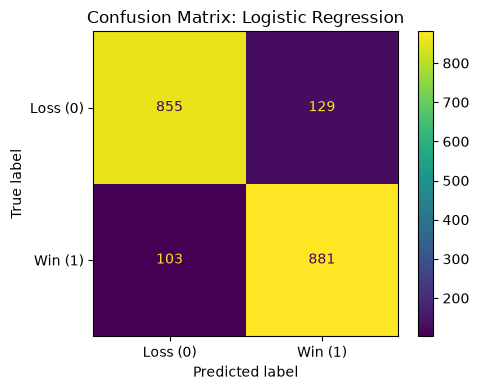

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Loss (0)", "Win (1)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap=None)  
ax.set_title("Confusion Matrix: Logistic Regression")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Interpretation

- The model achieves ~0.88 accuracy with balanced precision/recall.
- The confusion matrix shows errors are present for both classes (Wins and Losses), meaning the remaining non-leaky boxscore features are informative but not perfectly decisive.
- Logistic Regression was chosen as an interpretable baseline and works well with one-hot encoded categorical variables.
